In [2]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# importing the dataset
df_sales = pd.read_excel('Python real_world_sales_data.xlsx')
df_sales.head()

,order_id,customer_name,product,category,quantity,unit_price,payment_method,city,order_date,total_amount
0,1001,Adebayo,Laptop,Electronics,1,350000,Card,Lagos,2024-01-01,350000
1,1002,Chinedu,Phone,Electronics,2,180000,Transfer,Abuja,2024-01-02,360000
2,1003,Fatima,Tablet,Electronics,1,150000,Cash,Ibadan,2024-01-03,150000
3,1004,John,Headset,Accessories,3,12000,Card,Benin,2024-01-04,36000
4,1005,Aisha,Power Bank,Accessories,2,20000,Transfer,Port Harcourt,2024-01-05,40000


**_EDA_**

In [4]:
print(f"Information about the dataset \n{df_sales.info()}")
print(f"Statistics about the dataset \n{df_sales.describe()}")
print(f"Shape of the dataset \n{df_sales.shape}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        50 non-null     int64         
 1   customer_name   50 non-null     object        
 2   product         50 non-null     object        
 3   category        50 non-null     object        
 4   quantity        50 non-null     int64         
 5   unit_price      50 non-null     int64         
 6   payment_method  50 non-null     object        
 7   city            50 non-null     object        
 8   order_date      50 non-null     datetime64[ns]
 9   total_amount    50 non-null     int64         
dtypes: datetime64[ns](1), int64(4), object(5)
memory usage: 4.0+ KB
Information about the dataset 
None
Statistics about the dataset 
         order_id   quantity     unit_price           order_date  \
count    50.00000  50.000000      50.000000                   50   
me

### Cleaning

In [5]:
print(f"Check for missing values \n{df_sales.isnull().sum()}")
print(f"Number of duplicate in order_id: {df_sales["order_id"].duplicated().sum()}")

Check for missing values 
order_id          0
customer_name     0
product           0
category          0
quantity          0
unit_price        0
payment_method    0
city              0
order_date        0
total_amount      0
dtype: int64
Number of duplicate in order_id: 0


### **Revenue Overview**

What is the total revenue generated?

In [6]:

total_revenue = df_sales["total_amount"].sum()
print(f"Total revenue generated: N{total_revenue}")

Total revenue generated: N9360000


What is the average order value?

In [7]:
# Average order value
average_order_value = df_sales["total_amount"].mean()
print(f"Average order value: N{average_order_value}")

Average order value: N187200.0


How many total orders were placed?

In [8]:
# Total orders placed
total_orders = df_sales["order_id"].nunique()
print(f"Total orders placeed: {total_orders}")

Total orders placeed: 50


### **Product Analysis**

Which products generate the highest revenue?

In [9]:
# Product with the highest sales
top_product = df_sales.groupby("product")["total_amount"].sum().idxmax()
revenue_top_product = df_sales.groupby("product")["total_amount"].sum().max()
print(f"Product with the highest sales: {top_product} with revenue of N{revenue_top_product}")

Product with the highest sales: Phone with revenue of N3600000


Which products perform the worst?

In [10]:
# Worst performing product
worst_product = df_sales.groupby("product")["total_amount"].sum().idxmin()
revenue_worst_product = df_sales.groupby("product")["total_amount"].sum().min()
print(f"Product with the lowest sales: {worst_product} with revenue of N{revenue_worst_product}")

Product with the lowest sales: Headset with revenue of N360000


Based on the data, which ONE product should the company invest more in?

The company should invest more in phones then headset, since it makes ten times more sells then the later. However its crucial to understand that, not everybody that buys phone do buy headset. 

### **City Performance**

Which city generates the highest revenue?

In [11]:
# City with the highest sales
top_city = df_sales.groupby("city")["total_amount"].sum().idxmax()
revenue_top_city = df_sales.groupby("city")["total_amount"].sum().max()
print(f"City with the highest sales: {top_city} with revenue of N{revenue_top_city}")

City with the highest sales: Abuja with revenue of N3600000


Which city generates the lowest revenue?

In [12]:
# City with the lowest sales
lowest_city = df_sales.groupby("city")["total_amount"].sum().idxmin()
revenue_lowest_city = df_sales.groupby("city")["total_amount"].sum().min()
print(f"City with the lowest sales: {lowest_city} with revenue of N{revenue_lowest_city}")

City with the lowest sales: Benin with revenue of N360000


What is the average order value for each city?

In [13]:
# Average order value for each city
average_order_value_city = df_sales.groupby("city")["total_amount"].mean()
print(f"Average order value for each city: \n{average_order_value_city}")

Average order value for each city: 
city
Abuja            360000.0
Benin             36000.0
Ibadan           150000.0
Lagos            350000.0
Port Harcourt     40000.0
Name: total_amount, dtype: float64


Should the company expand operations in the top-performing city?

Yes of course, both Abuja and Lagos are ten and nine times respectively when compared with Benin, expanding operation in Ibadan will boost the sales more, since its already making almost half of what Abuja and Lagos are making.

### **Payment Behavior**

Which payment method is used most frequently?

In [14]:
# Highest payment method
top_payment_method = df_sales.groupby("payment_method")["total_amount"].sum().idxmax()
revenue_top_payment_method = df_sales.groupby("payment_method")["total_amount"].sum().max()
print(f"Payment method with the highest sales: {top_payment_method} with revenue of N{revenue_top_payment_method}")

Payment method with the highest sales: Transfer with revenue of N4000000


What percentage of transactions comes from each payment method?

In [15]:
# Percentage from each payment method
payment_method_percentage = df_sales.groupby("payment_method")["total_amount"].sum() / total_revenue * 100
print(f"Percentage of total revenue from each payment method: \n{payment_method_percentage}")

Percentage of total revenue from each payment method: 
payment_method
Card        41.239316
Cash        16.025641
Transfer    42.735043
Name: total_amount, dtype: float64


How much revenue is generated by each payment method?

In [16]:
# Revvenue generated by each payment method
revenue_by_payment_method = df_sales.groupby("payment_method")["total_amount"].sum()
print(f"Revenue generated by each payment method: \n{revenue_by_payment_method}")

Revenue generated by each payment method: 
payment_method
Card        3860000
Cash        1500000
Transfer    4000000
Name: total_amount, dtype: int64


Should the company consider removing cash payments?

No, although 16% of the total revenue is generated through cash, the country financial policiy is not fully automated and no company will find easy appealing to accept 16% revenue loss.

### **Advanced Analysis**

Which city–product combination generates the highest revenue?

In [17]:
# highest revenue by a city and product
city_product_revenue = df_sales.groupby(["city", "product"])["total_amount"].sum().idxmax()
highest_city_product = df_sales.groupby(["city", "product"])["total_amount"].sum().max()
print(f"Highest revenue by a city and product: \n{city_product_revenue} with revenue of N{highest_city_product}")

Highest revenue by a city and product: 
('Abuja', 'Phone') with revenue of N3600000


What is the average quantity purchased per order?

In [18]:
# Average quantity purchased by orders
average_quantity = df_sales["quantity"].mean()
print(f"Average quantity purchased by orders: {average_quantity}")

Average quantity purchased by orders: 1.8


What percentage of total revenue does each product contribute?

In [19]:
# percentage of revenue by each product
perc_revenue_by_product = df_sales.groupby("product")["total_amount"].sum() / total_revenue * 100
print(f"Percentage of revenue by each product: \n{perc_revenue_by_product}")

Percentage of revenue by each product: 
product
Headset        3.846154
Laptop        37.393162
Phone         38.461538
Power Bank     4.273504
Tablet        16.025641
Name: total_amount, dtype: float64


Create an order size classification (Small, Medium, Large). Which group generates the most revenue?

In [20]:
# Create order size categories
bins = [0, 1, 2, 3]
labels = ["Small", "Medium", "Large"]
df_sales["order_size"] = pd.cut(df_sales["quantity"], bins=bins, labels=labels)
# Group with the highest revenue by order size
top_order_size = df_sales.groupby("order_size")["total_amount"].sum().idxmax()
revenue_top_order_size = df_sales.groupby("order_size")["total_amount"].sum().max()
print(f"Order size category with the highest revenue: {top_order_size} with revenue of N{revenue_top_order_size}")

Order size category with the highest revenue: Small with revenue of N5000000


C:\Users\PC\AppData\Local\Temp\ipykernel_18208\3071897858.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_order_size = df_sales.groupby("order_size")["total_amount"].sum().idxmax()
C:\Users\PC\AppData\Local\Temp\ipykernel_18208\3071897858.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revenue_top_order_size = df_sales.groupby("order_size")["total_amount"].sum().max()


Who are the top 5 customers by total spending

In [21]:
# Top 5 customers by revenue
top_customers = df_sales.groupby("customer_name")["total_amount"].sum().nlargest(5)
print(f"Top 5 customers by revenue: \n{top_customers}")

Top 5 customers by revenue: 
customer_name
Blessing    1800000
Chinedu     1800000
Adebayo     1750000
Musa        1750000
Fatima       750000
Name: total_amount, dtype: int64


### **Visualization Tasks**

Create a chart showing revenue by product.

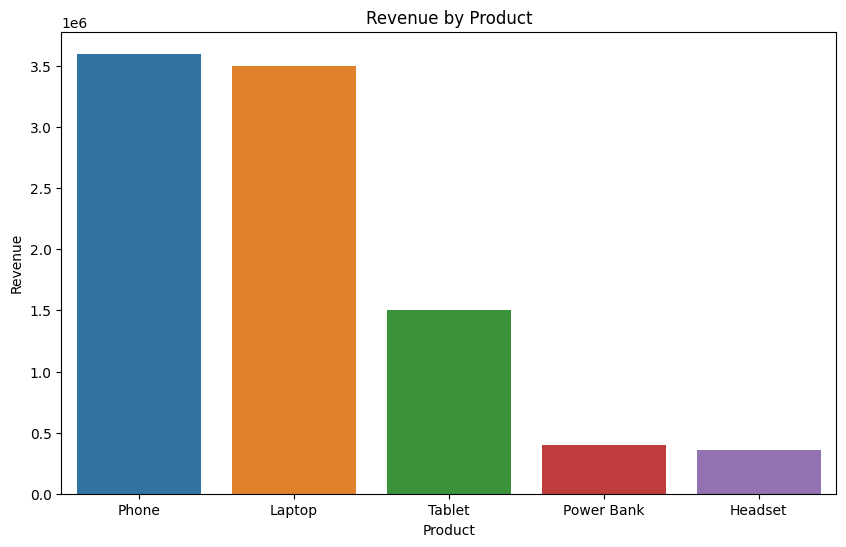

In [22]:
# Create a chart showing revenue by product.
revenue_by_product = df_sales.groupby("product")["total_amount"].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=revenue_by_product.index, y=revenue_by_product.values, hue=revenue_by_product.index)
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.title("Revenue by Product")
plt.show()

Create a chart showing revenue by city.

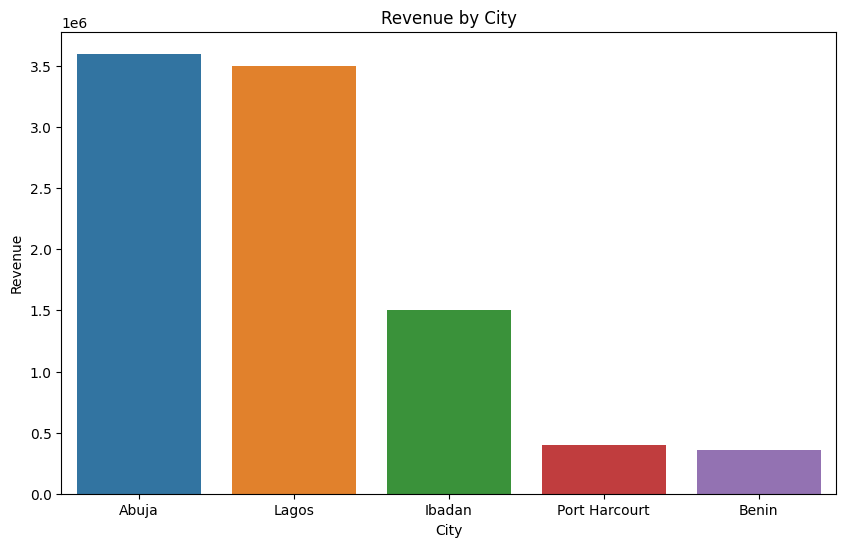

In [23]:
# Create a chart showing revenue by city.
revenue_by_city = df_sales.groupby("city")["total_amount"].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=revenue_by_city.index, y=revenue_by_city.values, hue=revenue_by_city.index)
plt.xlabel("City")
plt.ylabel("Revenue")
plt.title("Revenue by City")
plt.show()

Create a chart showing payment method distribution.

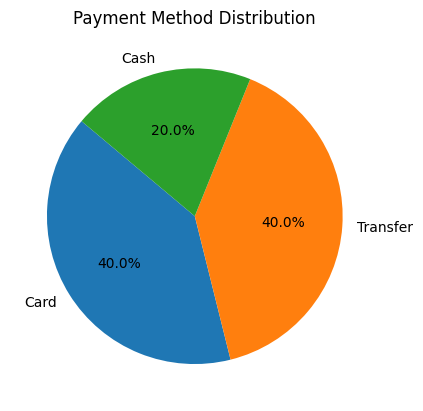

In [25]:
# Create a chart showing payment method distribution.
payment_method_counts = df_sales["payment_method"].value_counts()
plt.pie(payment_method_counts.values, labels=payment_method_counts.index, autopct="%1.1f%%", startangle=140)
plt.title("Payment Method Distribution")
plt.show()